# Analysis
This notebook includes analysis pipelines to examine the accuracy of the synthetic trials

In [1]:
import sys
sys.path.append('../src')
import matplotlib.pyplot as plt
plt.style.core.USER_LIBRARY_PATHS.append('/gscratch/matsulab/utils/ctleelab-mpl-utilities/ctleelab_plothelper')
plt.style.reload_library()

In [2]:
# create dictionary
# the calculation is based on Mem3DG pulg-in functions
# notebook: Mem3DG/tests/python/pinn_synthetic/calc_mesh_properties.ipynb

area_mem = {
    "biconcave": 4.509775652390608,
    # "bud":       4.767351221422792, # for margin_ratio = -0.2
    # "bud": 4.79, # test
    # "bud":       8.475291060307185,
    "bud_04":       5.187943386967171,  # for margin_ratio = -0.4
    "multi":      5.257892208208614 + 0.8607915589346745
}

bend_mem = {
    "biconcave": 34.23409861449123,
    "bud":       21.941595635908413,
    "bud_04":       21.941595635908413,
    "multi":     30.912018724759164 + 25.420889021757755
}

In [3]:
# Dice Loss (single calculation)
from pinn.analysis import dice_loss
from flax.training import checkpoints
import os

# parameters
grid_size = 64
lambda_1 = 1000000
lambda_2 = 0
step = 10000
epsilon = 0.05
# shape = "biconcave"
shape = "bud"

# import data
ckpt_dir = os.path.abspath(f"../outputs/logs/{shape}/clean/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
dat_seg = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)
mrc_path = f"../data/synthetic/{shape}.mrc"

loss = dice_loss(mrc_path, dat_seg, grid_size=grid_size, threshold=0.8, band_thickness=0.2)
print("Dice loss:", loss)


TypeError: 'NoneType' object is not subscriptable

In [ ]:
# Visualize masks

import matplotlib.pyplot as plt
import numpy as np
import os
from flax.training import checkpoints
from pinn.analysis import dice_loss, get_masks, visualize_masks, surface_dice

# parameters
lambda_1 = 1000000
lambda_2 = 0
step = 10000
epsilon = 0.05
shape = "bud_04"
# shape = "multi"
grid_size = 64

# import data
# ckpt_dir = os.path.abspath(f"../outputs/logs/{shape}/clean/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
ckpt_dir = os.path.abspath(f"../outputs/logs/{shape}/data_1115/combine/a015_m08/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
dat_seg = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)
mrc_path = f"../data/synthetic/{shape}.mrc"

# loss = dice_loss(mrc_path, dat_seg, grid_size=grid_size, threshold=threshold, )
gt_mask, gt_sklt, pred_mask, pred_sklt = get_masks(mrc_path, dat_seg, grid_size=64, threshold=0.6, band_thickness=0.4)

# visualize
# visualize_masks(gt_mask, pred_mask, axis=0)  # z-slice
visualize_masks(gt_mask, pred_sklt, axis=1)  # y-slice
visualize_masks(gt_sklt, pred_mask, axis=1)  # y-slice
# visualize_masks(gt_mask, pred_mask, axis=2)  # x-slice

vol_dice = dice_loss(mrc_path, dat_seg, grid_size=grid_size, threshold=0.8, band_thickness=0.2)
srf_dice = surface_dice(mrc_path, dat_seg, grid_size=grid_size, threshold=0.6, band_thickness=0.4)
print(vol_dice, srf_dice)


In [ ]:
# Area and Energy (indivisual calculation)

import os
import numpy as np
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.analysis import calc_area_mem, calc_bend_mem
from pinn.analysis import calc_area_seg, calc_bend_seg

# parameters
GRID_SIZE = 64
lambda_1 = 1000000
lambda_2 = 100
step = 10000
epsilon = 0.05
kappa = 1
# shape = "biconcave"
shape = "bud"
# shape = "multi"

# import data
ckpt_dir = os.path.abspath(f"../outputs/logs/{shape}/clean/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
dat_seg = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)
mrc_path = f"../data/synthetic/{shape}.mrc"

area_mrc = calc_area_mem(mrc_path, iso_value=0.8)
area_seg = calc_area_seg(dat_seg, epsilon=epsilon, sampling="random", num_point=10000)
print("Area: ", area_mem[shape], area_seg, np.abs(area_mem[shape] - area_seg)/area_mem[shape])
print("Area: ", area_mrc, area_seg, np.abs(area_mrc - area_seg)/area_mrc)

# bend_mrc = calc_bend_mem(mrc_path, iso_value=0.8)
bend_seg = calc_bend_seg(dat_seg, epsilon=epsilon, kappa=kappa, sampling="random", num_point=10000)
print("Bend: ", bend_mem[shape], bend_seg, np.abs(bend_mem[shape] - bend_seg)/bend_mem[shape])
# print(bend_mrc, bend_seg, np.abs(bend_mrc - bend_seg)/bend_mrc)



In [ ]:
# Dice, Area and Energy (comparison using bar graph)

import os
import numpy as np
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.analysis import calc_area_seg, calc_bend_seg, dice_loss
import matplotlib.pyplot as plt

from pinn.analysis import calc_area_mem, calc_bend_mem
from pinn.analysis import calc_area_seg, calc_bend_seg

# parameters
lambda_1 = 1000000
lambda_2_list = [0, 10, 30, 50, 100]
step = 10000
epsilon = 0.05
kappa = 1
# shape = "biconcave"
# shape = "bud_04"
shape = "multi"

dice_los_dict = {}
area_seg_dict = {}
bend_seg_dict = {}


# calculation of the surface area based on MRC
mrc_path = f"../data/synthetic/{shape}.mrc"
area_mrc = calc_area_mem(mrc_path, iso_value=0.8)


for lambda_2 in lambda_2_list:

    # import data
    ckpt_dir = os.path.abspath(f"../outputs/logs/{shape}/data_0926/clean/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
    dat_seg = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)
    mrc_path = f"../data/synthetic/{shape}.mrc"

    dice_los = dice_loss(mrc_path, dat_seg, grid_size=64, threshold=0.8, band_thickness=0.2)
    area_seg = calc_area_seg(dat_seg, epsilon=epsilon, sampling="random", num_point=10000)
    bend_seg = calc_bend_seg(dat_seg, epsilon=epsilon, kappa=kappa, sampling="random", num_point=10000)

    dice_los_dict[lambda_2] = dice_los
    area_seg_dict[lambda_2] = np.abs(area_mem[shape] - area_seg) / area_mem[shape]
    # area_seg_dict[lambda_2] = np.abs(area_mrc - area_seg) / area_mem[shape]
    bend_seg_dict[lambda_2] = np.abs(bend_mem[shape] - bend_seg) / bend_mem[shape]




# Extract keys and values
labels = list(area_seg_dict.keys())
dice_losses = [float(dice_los_dict[k]) for k in labels]
area_values = [float(area_seg_dict[k]) for k in labels]
bend_values = [float(bend_seg_dict[k]) for k in labels]
x_pos = range(len(labels))

# Create two subplots side by side
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(8, 4), sharex=True)

# plot 0: dice loss
ax0.bar(x_pos, dice_losses)
ax0.set_xticks(x_pos)
ax0.set_xticklabels(labels)
ax0.set_xlabel(r"Physics weight,  $\lambda_p$")
ax0.set_ylabel(r"$1 - Dice$")
ax0.set_title(r"Dice loss")
ax0.set_ylim(0, 1)

# plot 1: area
ax1.bar(x_pos, area_values)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels)
ax1.set_xlabel(r"Physics weight,  $\lambda_p$")
# ax1.set_ylabel(r"$\Delta A / A$")
# ax1.set_title(r"Surface area error")
ax1.set_ylabel(r"$\Delta E_s / E_s$")
ax1.set_title(r"Tension energy error")
ax1.set_ylim(0, 1)

# plot2: bending
ax2.bar(x_pos, bend_values)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(labels)
ax2.set_xlabel(r"Physics weight,  $\lambda_p$")
ax2.set_ylabel(r"$\Delta E_b / E_b$")
ax2.set_title(r"Bending energy error")
ax2.set_ylim(0, 5)

# annotate outliers automatically
for xpos, val in zip(x_pos, bend_values):
    if val > 5:  # exceeds ylim
        ax2.text(xpos, 4.7, f"{val:.2f}↑", ha="center", va="bottom", fontsize=7)


plt.tight_layout()
plt.show()



/tmp/ipykernel_93925/40248499.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


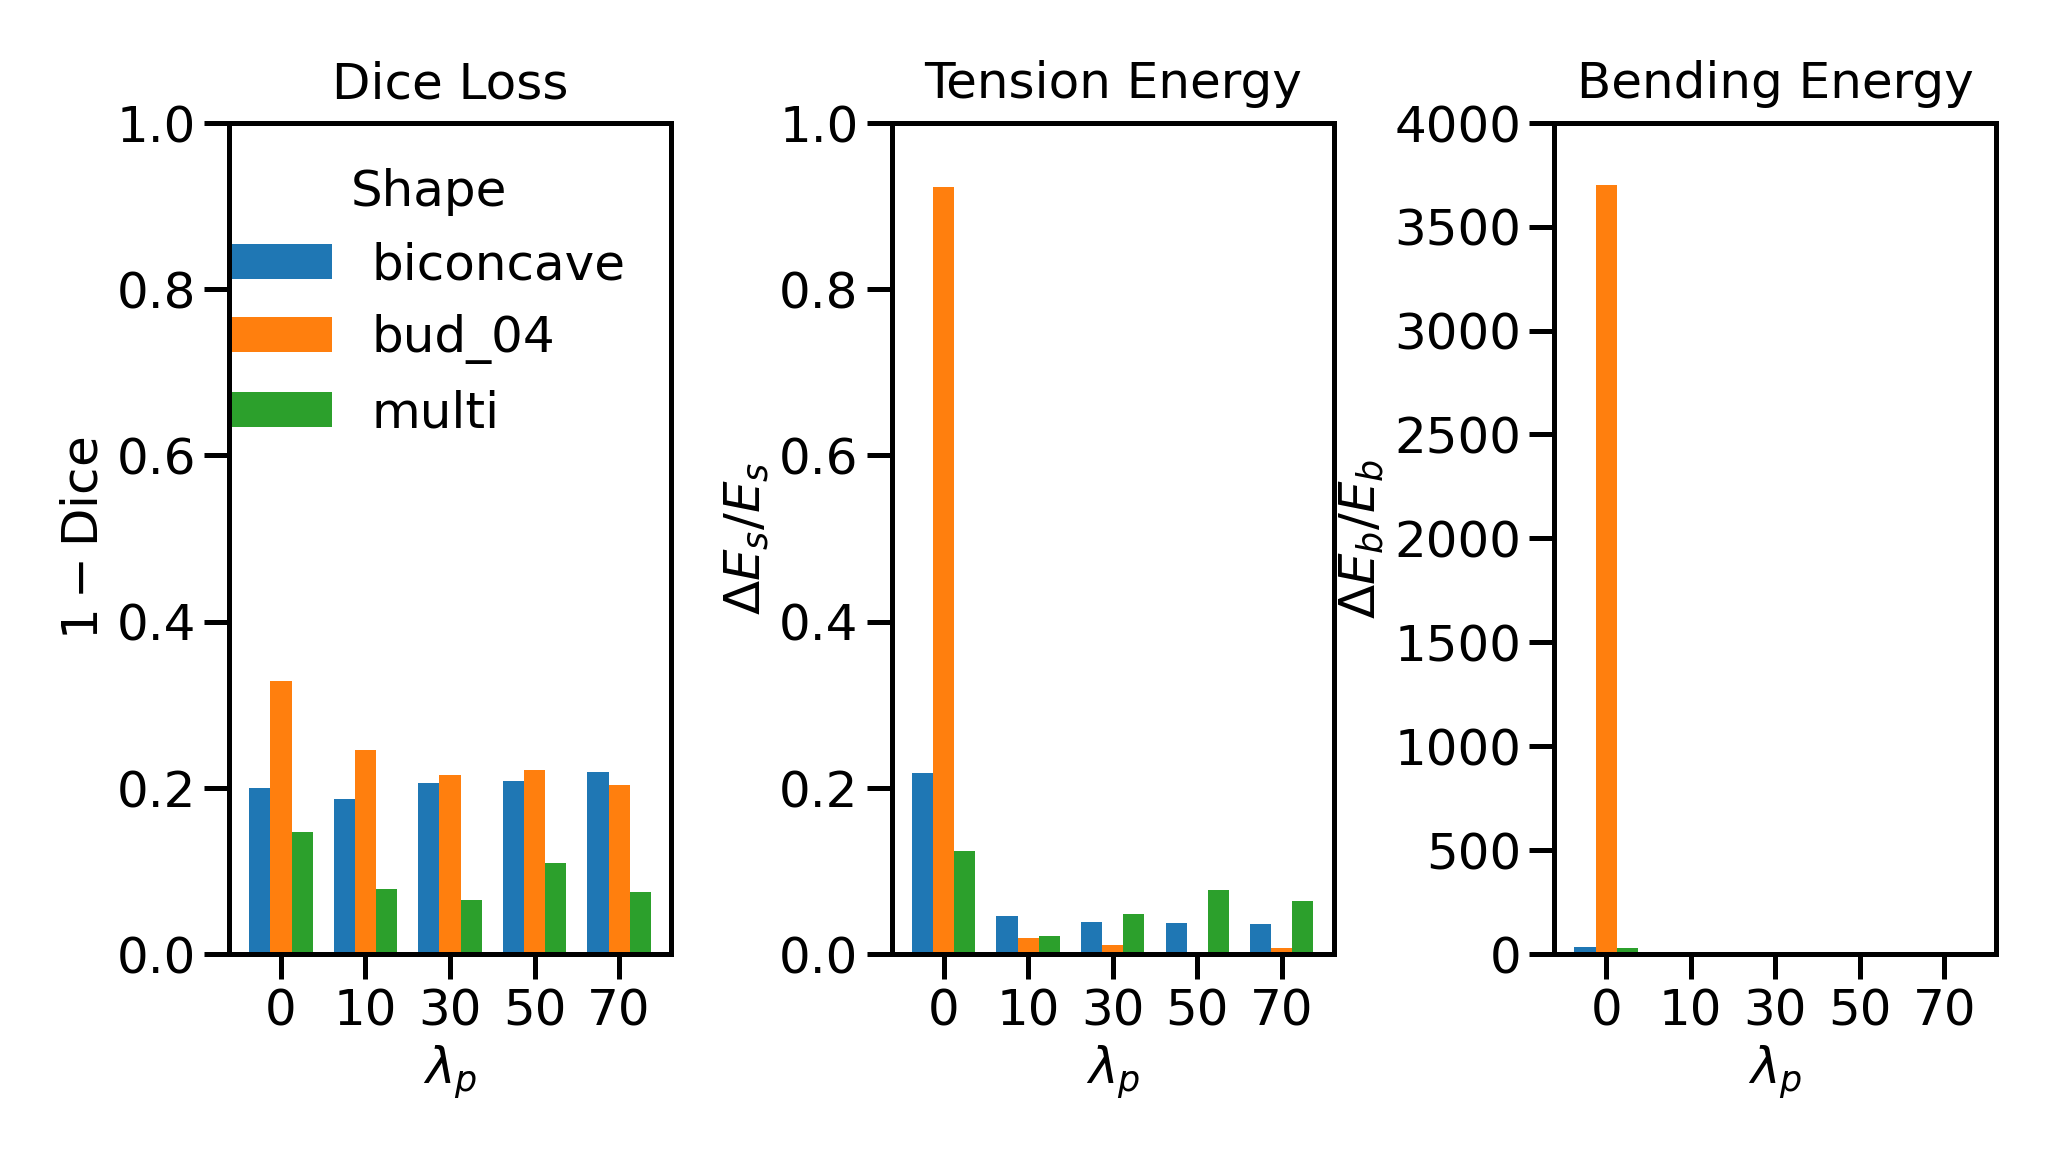

In [37]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.analysis import dice_loss, surface_dice
from pinn.analysis import calc_area_mem, calc_bend_mem
from pinn.analysis import calc_area_seg, calc_bend_seg
from matplotlib.ticker import FormatStrFormatter

# -------------------
# Parameters
# -------------------
lambda_1 = 1000000
lambda_2_list = [0, 10, 30, 50, 70]
# lambda_2_list = [0, 10, 50, 100]
step = 10000
epsilon = 0.05
kappa = 1.0
shapes = ["biconcave", "bud_04", "multi"]
data_type = "1115"
# data_type = "1203"
flip_ratio = 0.15
missing_ratio = 0.7
axis_angle = 40
tilt_max = 50

flip_str = str(flip_ratio).replace('.', '')
missing_str = str(missing_ratio).replace('.', '')

# -------------------
# Storage
# -------------------
results = {key: {s: {} for s in shapes} for key in ["dice", "area_err", "bend_err"]}

# -------------------
# Main loop
# -------------------
for shape in shapes:
    # Ground truth from MRC
    mrc_path = f"../data/synthetic/{shape}.mrc"
    # area_true = calc_area_mem(mrc_path, iso_value=0.8)
    area_true = area_mem[shape]
    bend_true = bend_mem[shape]

    for lam2 in lambda_2_list:
        # ckpt_dir = os.path.abspath(f"../outputs/logs/{shape}/data_{data_type}/clean/sphere/lambda_{lambda_1}_{lam2}/checkpoint_{step}")    
        # ckpt_dir = os.path.abspath(f"../outputs/logs/{shape}/data_{data_type}/combine/a{flip_str}_m{missing_str}/lambda_{lambda_1}_{lam2}/checkpoint_{step}") 
        ckpt_dir = os.path.abspath(f"../outputs/logs/{shape}/data_{data_type}/wedge/a{flip_str}_w{axis_angle:02d}_t{tilt_max:02d}/lambda_{lambda_1}_{lam2}/checkpoint_{step}") 

        # if shape == "biconcave":
        #     ckpt_dir = os.path.abspath(f"../outputs/logs/{shape}/data_{data_type}/combine/a{flip_str}_m{missing_str}/lambda_{lambda_1}_{lam2}/checkpoint_{step}")
        # else:
        #     ckpt_dir = os.path.abspath(f"../outputs/logs/{shape}/data_{data_type}/combine-sphere/a{flip_str}_m{missing_str}/lambda_{lambda_1}_{lam2}/checkpoint_{step}") 
            
            
        dat_seg = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)

        # dice_val = dice_loss(mrc_path, dat_seg, grid_size=64, threshold=0.8, band_thickness=0.2)
        dice_val = surface_dice(mrc_path, dat_seg, grid_size=64, threshold=0.6, band_thickness=0.4)
        area_seg_val = calc_area_seg(dat_seg, epsilon=epsilon, sampling="random", num_point=10000)
        bend_seg_val = calc_bend_seg(dat_seg, epsilon=epsilon, kappa=kappa, sampling="random", num_point=10000)

        results["dice"][shape][lam2] = float(dice_val)
        results["area_err"][shape][lam2] = float(abs(area_true - area_seg_val) / area_true)       
        results["bend_err"][shape][lam2] = float(abs(bend_true - bend_seg_val) / bend_true)
        # results["area_err"][shape][lam2] = float((area_seg_val - area_true) / area_true)
        # results["bend_err"][shape][lam2] = float((bend_seg_val - bend_true) / bend_true)

# -------------------
# Plotting: x-axis = λ₂, colors = shapes
# -------------------
metrics = [
    ("dice", r"$1 - \mathrm{Dice}$", "Dice Loss"),
    # ("area_err", r"$\Delta A / A$", "Surface area error"),
    ("area_err", r"$\Delta E_s / E_s$", "Tension Energy"),    
    ("bend_err", r"$\Delta E_b / E_b$", "Bending Energy"),
]

x = np.arange(len(lambda_2_list))  # positions: [0,1,2,3]
w = 0.25                           # bar width

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):
    
    fig, axes = plt.subplots(1, len(metrics), figsize=(3.8, 1.8), sharey=False, gridspec_kw={'wspace': 0.5})
    # fig, axes = plt.subplots(1, len(metrics), figsize=(3.8, 1.3), sharey=False, gridspec_kw={'wspace': 0.5})
    
    for ax, (key, ylab, title) in zip(axes, metrics):
        for i, shape in enumerate(shapes):
            vals = [results[key][shape][lam2] for lam2 in lambda_2_list]
            ax.bar(x + (i - (len(shapes)-1)/2)*w, vals, width=w, label=shape)
    
        ax.set_xticks(x)
        ax.set_xticklabels(lambda_2_list)
        # ax.set_xlabel(r"Physics weight,  $\lambda_p$")
        ax.set_xlabel(r"$\lambda_p$")
        ax.set_ylabel(ylab)
        ax.set_title(title)

    
        if key == "dice":
            ax.set_ylim(0, 1.0)
        elif key == "area_err":
            ax.set_ylim(0, 1)
            # ax.set_ylim(0, 1.8)
        elif key == "bend_err":
            # ax.set_ylim(0, 9)
            # ax.set_ylim(0, 50)
            # ax.set_ylim(0, 250)
            ax.set_ylim(0, 4000)
        
            # # annotate outlier (lam2 = 0, shape="bud")
            # for i, shape in enumerate(shapes):
            #     val = results[key][shape][0]   # lam2 = 0
            #     if val > 10:  # outside ylim
            #         xpos = x[0] + (i - (len(shapes)-1)/2)*w  # bar position
            #         ax.text(xpos, 9, f"{val:.2f}↑", ha="center", va="bottom", fontsize=2, rotation=90)
    
 
    # for ax in axes:
        # ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))   
    
    axes[0].legend(title="Shape", frameon=False)
    
    plt.tight_layout()
    # plt.savefig(f"../outputs/figs/sync/energy_error.pdf", bbox_inches="tight")
    # plt.savefig(f"../outputs/figs/sync/noise/energy_error_a{flip_str}_m{missing_str}.pdf", bbox_inches="tight")
    # plt.savefig(f"../outputs/figs/sync/noise/energy_error_tension_a{flip_str}_m{missing_str}.pdf", bbox_inches="tight")    
    # plt.savefig(f"../outputs/figs/sync/energy_error_f{flip_str}.pdf", bbox_inches="tight")
    plt.savefig(f"../outputs/figs/sync/wedge/energy_error_a{flip_str}_w{axis_angle:02d}_t{tilt_max:02d}.pdf", bbox_inches="tight")
    plt.show()



In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.analysis import dice_loss
from pinn.analysis import calc_area_mem, calc_bend_mem
from pinn.analysis import calc_area_seg, calc_bend_seg
from matplotlib.ticker import FormatStrFormatter

# -------------------
# Parameters
# -------------------
lambda_1 = 1000000
# lambda_2_list = [0, 10, 30, 50, 70]
lambda_2_list = [0, 10, 20, 30]
step = 10000
epsilon = 0.05
kappa = 1.0
shapes = ["biconcave", "bud_04", "multi"]
# flip_ratio_list = [0.1, 0.15, 0.2]
# nosie_list = [0.15, 0.2, 0.25]
noise_list = [0.75, 0.85, 0.95]

# -------------------
# Storage
# -------------------
results = {key: {s: {} for s in shapes} for key in ["dice", "area_err", "bend_err"]}

# -------------------
# Main loop
# -------------------
for shape in shapes:
    mrc_path = f"../data/synthetic/{shape}.mrc"
    area_true = area_mem[shape]
    bend_true = bend_mem[shape]

    for lam2 in lambda_2_list:
        for noise in noise_list:
            noise_str = str(noise).replace('.', '')

            # if shape == "multi":
            #     ckpt_dir = os.path.abspath(f"../outputs/logs/{shape}/data_0926/f{flip_str}/lambda_{lambda_1}_{lam2}/checkpoint_{step}")
            # else:
            #     ckpt_dir = os.path.abspath(f"../outputs/logs/{shape}/data_1027/f{flip_str}/lambda_{lambda_1}_{lam2}/checkpoint_20000")

            # ckpt_dir = os.path.abspath(f"../outputs/logs/{shape}/data_1115/a{nosie_str}/lambda_{lambda_1}_{lam2}/checkpoint_{step}")
            ckpt_dir = os.path.abspath(f"../outputs/logs/{shape}/data_1115/m{noise_str}/lambda_{lambda_1}_{lam2}/checkpoint_{step}")

            dat_seg = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)

            dice_val = dice_loss(mrc_path, dat_seg, grid_size=64, threshold=0.8, band_thickness=0.2)
            area_seg_val = calc_area_seg(dat_seg, epsilon=epsilon, sampling="random", num_point=10000)
            bend_seg_val = calc_bend_seg(dat_seg, epsilon=epsilon, kappa=kappa, sampling="random", num_point=10000)

            # make sure the nested dicts exist
            if lam2 not in results["dice"][shape]:
                results["dice"][shape][lam2] = {}
                results["area_err"][shape][lam2] = {}
                results["bend_err"][shape][lam2] = {}

            # assign values
            results["dice"][shape][lam2][noise] = float(dice_val)
            results["area_err"][shape][lam2][noise] = float(abs(area_true - area_seg_val) / area_true)
            results["bend_err"][shape][lam2][noise] = float(abs(bend_true - bend_seg_val) / bend_true)


In [ ]:
key = "dice"
lambda_2_list = [0, 10, 20, 30]
# lambda_2_list = [10, 30, 50, 70]
# flip_ratio_list = [0.1, 0.15, 0.2]

# noise_list = [0.15, 0.2, 0.25]
# noise_list = [0.75, 0.85, 0.95]
noise_list = [0.75, 0.85, 0.95]

x = np.arange(len(lambda_2_list))        # [0,1,2,3,4]
w = 0.8 / max(1, len(shapes))            # bar width scaled by number of shapes

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    fig, axes = plt.subplots(1, len(flip_ratio_list), figsize=(3.8, 1.2), sharey=True,
                             gridspec_kw={'wspace': 0.1})

    if len(noise_list) == 1:
        axes = [axes]

    for ax, noise in zip(axes, noise_list):
        for i, shape in enumerate(shapes):
            vals = [float(results[key][shape][lam2][noise]) for lam2 in lambda_2_list]
            offset = (i - (len(shapes)-1)/2) * w
            ax.bar(x + offset, vals, width=w, label=shape)

        ax.set_xticks(x)
        ax.set_xticklabels(lambda_2_list)
        ax.set_xlabel(r"$\lambda_p$")
        ax.set_title(f"Noise Level: {noise:g}")
        if key == "dice":
            ax.set_ylim(0, 1.0)
        else:
            # ax.set_ylim(0, 200)
            # ax.set_ylim(0, 120)            
            ax.set_ylim(0, 1)
        ax.grid(False)

    if key == "dice":
        axes[0].set_ylabel(r"$1 - \mathrm{Dice}$")
    elif key == "area_err":
        axes[0].set_ylabel(r"$\Delta E_s / E_s$")
    elif key == "bend_err":
        axes[0].set_ylabel(r"$\Delta E_b / E_b$")

    axes[0].legend(title="Shape", frameon=False, loc="upper right", bbox_to_anchor=(1.0, 1.0))

    plt.tight_layout()
    # Example save (optional):
    # plt.savefig(f"../outputs/figs/sync/energy_error_{key}.pdf", bbox_inches="tight")
    plt.show()



In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.analysis import dice_loss
from pinn.analysis import calc_area_mem, calc_bend_mem
from pinn.analysis import calc_area_seg, calc_bend_seg
from matplotlib.ticker import FormatStrFormatter

# -------------------
# Parameters
# -------------------
lambda_1 = 1000000
lambda_2_list = [0, 10, 30, 50, 70]
step = 10000
epsilon = 0.05
kappa = 1.0
shapes = ["biconcave", "bud_04", "multi"]
hetero_scale_list = [1, 5, 10]

# -------------------
# Storage
# -------------------
results = {key: {s: {} for s in shapes} for key in ["dice", "area_err", "bend_err"]}

# -------------------
# Main loop
# -------------------
for shape in shapes:
    mrc_path = f"../data/synthetic/{shape}.mrc"
    area_true = area_mem[shape]
    bend_true = bend_mem[shape]

    for lam2 in lambda_2_list:
        for hetero_scale in hetero_scale_list:

            hetero = hetero_scale
            if shape == "bud_04" and hetero == 5:
                hetero = 2
            if shape == "bud_04" and hetero == 10:
                hetero = 3
                
            ckpt_dir = os.path.abspath(f"../outputs/logs/{shape}/data_0926/h{hetero}/lambda_{lambda_1}_{lam2}/checkpoint_{step}")
            dat_seg = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)

            # print(ckpt_dir)

            dice_val = dice_loss(mrc_path, dat_seg, grid_size=64, threshold=0.8, band_thickness=0.2)
            area_seg_val = calc_area_seg(dat_seg, epsilon=epsilon, sampling="random", num_point=10000)
            bend_seg_val = calc_bend_seg(dat_seg, epsilon=epsilon, kappa=kappa, sampling="random", num_point=10000)

            # make sure the nested dicts exist
            if lam2 not in results["dice"][shape]:
                results["dice"][shape][lam2] = {}
                results["area_err"][shape][lam2] = {}
                results["bend_err"][shape][lam2] = {}

            # assign values
            results["dice"][shape][lam2][hetero_scale] = float(dice_val)
            results["area_err"][shape][lam2][hetero_scale] = float(abs(area_true - area_seg_val) / area_true)
            results["bend_err"][shape][lam2][hetero_scale] = float(abs(bend_true - bend_seg_val) / bend_true)

In [ ]:
key = "bend_err"
# lambda_2_list = [0, 10, 30, 50, 70]
lambda_2_list = [0, 10, 20, 30]
# noise_list = [1, 5, 10]
noise_list = [0.85, 0.95]

x = np.arange(len(lambda_2_list))        # [0,1,2,3,4]
w = 0.8 / max(1, len(shapes))            # bar width scaled by number of shapes

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    fig, axes = plt.subplots(1, len(noise_list), figsize=(3.8, 1.2), sharey=True,
                             gridspec_kw={'wspace': 0.1})

    for ax, noise in zip(axes, noise_list):
        for i, shape in enumerate(shapes):
            vals = [float(results[key][shape][lam2][noise]) for lam2 in lambda_2_list]
            offset = (i - (len(shapes)-1)/2) * w
            ax.bar(x + offset, vals, width=w, label=shape)

        ax.set_xticks(x)
        ax.set_xticklabels(lambda_2_list)
        ax.set_xlabel(r"$\lambda_p$")
        ax.set_title(f"Noise Level: {noise:g}")
        if key == "dice":
            ax.set_ylim(0, 1.0)
        else:
            ax.set_ylim(0, 10)
        ax.grid(False)

    if key == "dice":
        axes[0].set_ylabel(r"$1 - \mathrm{Dice}$")
    elif key == "area_err":
        axes[0].set_ylabel(r"$\Delta E_s / E_s$")
    elif key == "bend_err":
        axes[0].set_ylabel(r"$\Delta E_b / E_b$")

    axes[0].legend(title="Shape", frameon=False, loc="upper right", bbox_to_anchor=(1.0, 1.0))

    plt.tight_layout()
    # plt.savefig(f"../outputs/figs/sync/hetero_error_{key}.pdf", bbox_inches="tight")
    plt.show()

In [ ]:
# Visualize the surface extracted from an MRC file using marching cubes.
# Ensure that the chosen iso_value produces a surface where the membrane 
# is thin enough to be treated as a doubled membrane.

import trimesh
import mrcfile
from skimage import measure
import trimesh

shape = "biconcave"
mrc_path = f"../data/synthetic/{shape}.mrc"
iso_value = 0.8

with mrcfile.open(mrc_path) as mrc:
    volume = mrc.data.astype(np.float32)
nx, ny, nz = volume.shape

# Choose iso-value
if iso_value is None:
    iso_value = float(np.mean(volume))

# Marching cubes in voxel space
verts, faces, normals, values = measure.marching_cubes(volume, level=iso_value)

# Rescale vertices to [-1,1]^3
verts[:, 0] = 2.0 * verts[:, 0] / nx - 1.0
verts[:, 1] = 2.0 * verts[:, 1] / ny - 1.0
verts[:, 2] = 2.0 * verts[:, 2] / nz - 1.0

# Mesh & surface area
mesh = trimesh.Trimesh(vertices=verts, faces=faces, process=False)
mesh.show()


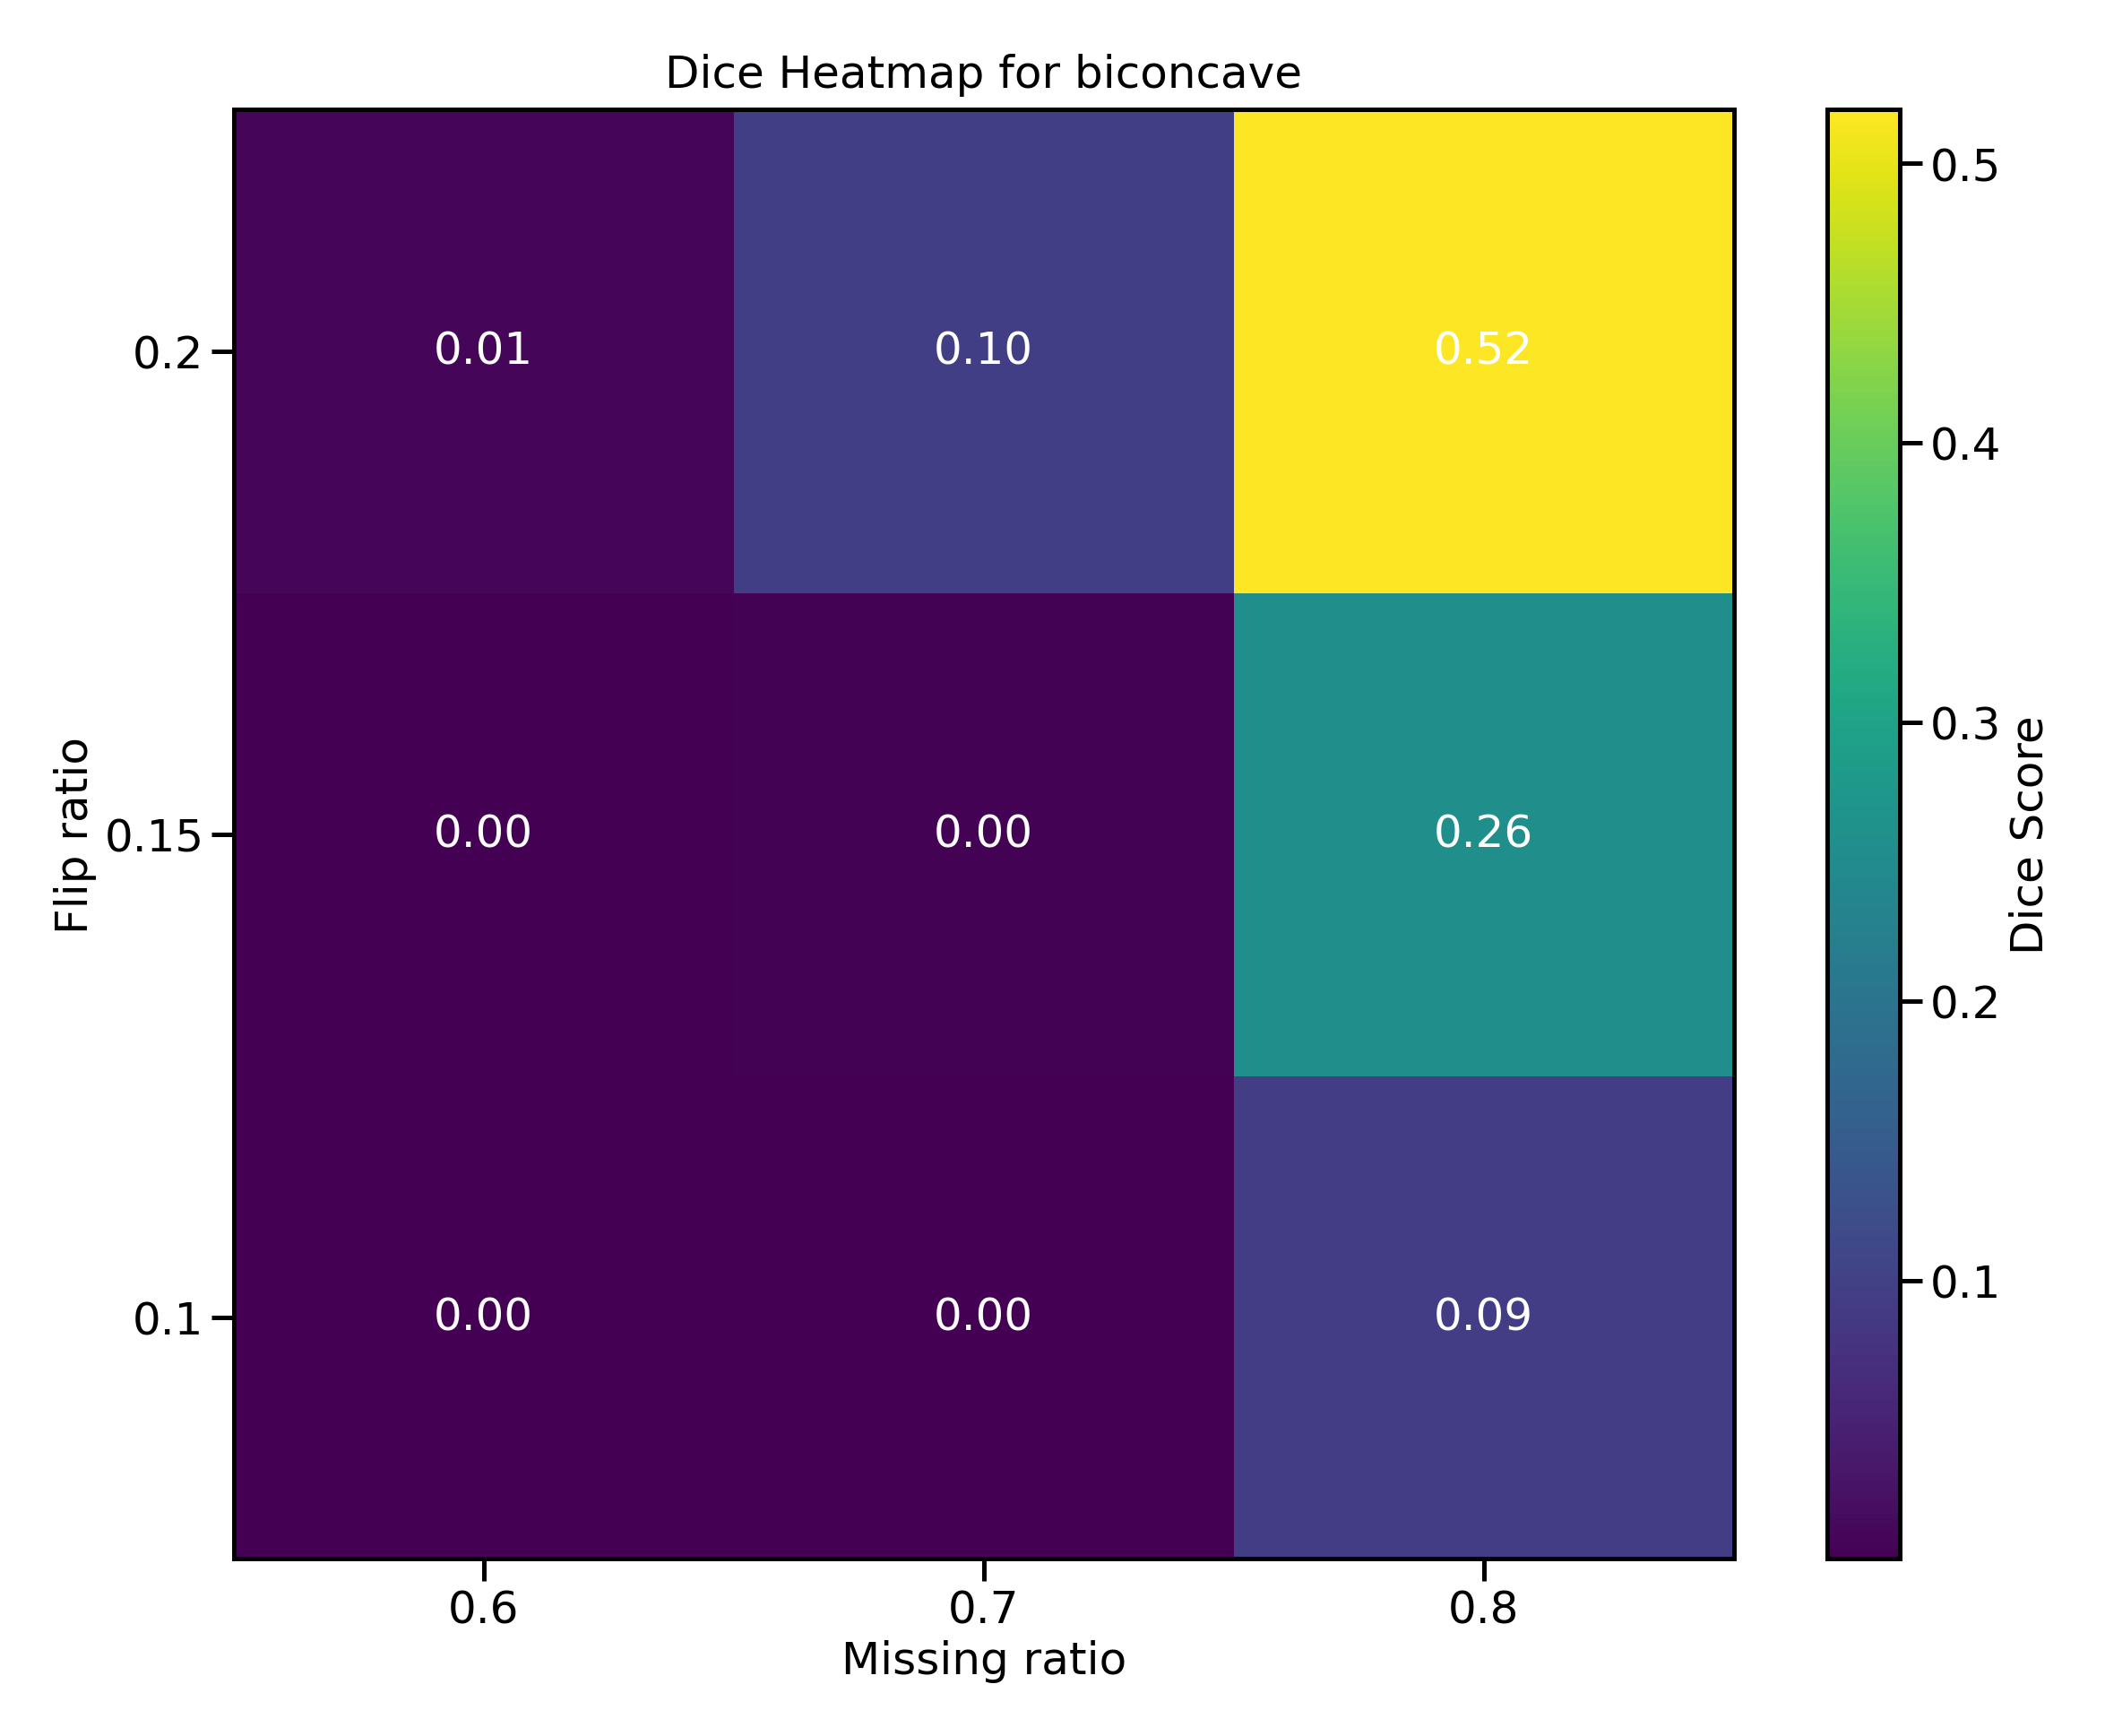

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.analysis import dice_loss, surface_dice
from pinn.analysis import calc_area_mem, calc_bend_mem
from pinn.analysis import calc_area_seg, calc_bend_seg

# -------------------
# Parameters
# -------------------
lambda_1 = 1000000
lambda_2 = 50
step = 10000
epsilon = 0.05
kappa = 1.0
shape = "biconcave"
data_type = "1115"

flip_list = [0.05, 0.1, 0.15, 0.2]
missing_list = [0.6, 0.7, 0.8]

# -------------------
# Storage
# -------------------
results = {key: {} for key in ["dice", "area_err", "bend_err"]}

# -------------------
# Ground truth from MRC
# -------------------
mrc_path = f"../data/synthetic/{shape}.mrc"
area_true = area_mem[shape]
bend_true = bend_mem[shape]

# -------------------
# Main loop
# -------------------
for flip_ratio in flip_list:
    for missing_ratio in missing_list:

        flip_str = str(flip_ratio).replace('.', '')
        missing_str = str(missing_ratio).replace('.', '')
        ckpt_dir = os.path.abspath(f"../outputs/logs/{shape}/data_{data_type}/combine/a{flip_str}_m{missing_str}/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}") 
        if not os.path.exists(ckpt_dir): continue
        dat_seg = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)

        dice_val = surface_dice(mrc_path, dat_seg, grid_size=64, threshold=0.6, band_thickness=0.4)
        # area_seg_val = calc_area_seg(dat_seg, epsilon=epsilon, sampling="random", num_point=10000)
        # bend_seg_val = calc_bend_seg(dat_seg, epsilon=epsilon, kappa=kappa, sampling="random", num_point=10000)

        results["dice"].setdefault(flip_ratio, {})[missing_ratio] = float(dice_val)
        # results["area_err"].setdefault(flip_ratio, {})[missing_ratio] = ...
        # results["bend_err"].setdefault(flip_ratio, {})[missing_ratio] = ...


import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Convert nested dict results → 2D array for heatmap
# ------------------------------------------------------------
flip_vals = sorted(results["dice"].keys())
missing_vals = sorted(list(results["dice"][flip_vals[0]].keys()))

heatmap = np.zeros((len(flip_vals), len(missing_vals)))

for i, flip_ratio in enumerate(flip_vals):
    for j, missing_ratio in enumerate(missing_vals):
        heatmap[i, j] = results["dice"][flip_ratio][missing_ratio]

# ------------------------------------------------------------
# Plot heatmap
# ------------------------------------------------------------

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    fig, ax = plt.subplots(figsize=(4.5, 3.5))

    im = ax.imshow(
        heatmap,
        origin="lower",
        aspect="auto",
    )

    # Colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Dice Score")

    # Tick labels
    ax.set_xticks(np.arange(len(missing_vals)))
    ax.set_yticks(np.arange(len(flip_vals)))

    ax.set_xticklabels(missing_vals)
    ax.set_yticklabels(flip_vals)

    ax.set_xlabel("Missing ratio")
    ax.set_ylabel("Flip ratio")
    ax.set_title(f"Dice Heatmap for {shape}")

    # Optional: annotate cells with numbers
    for i in range(len(flip_vals)):
        for j in range(len(missing_vals)):
            val = heatmap[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="white")

plt.show()



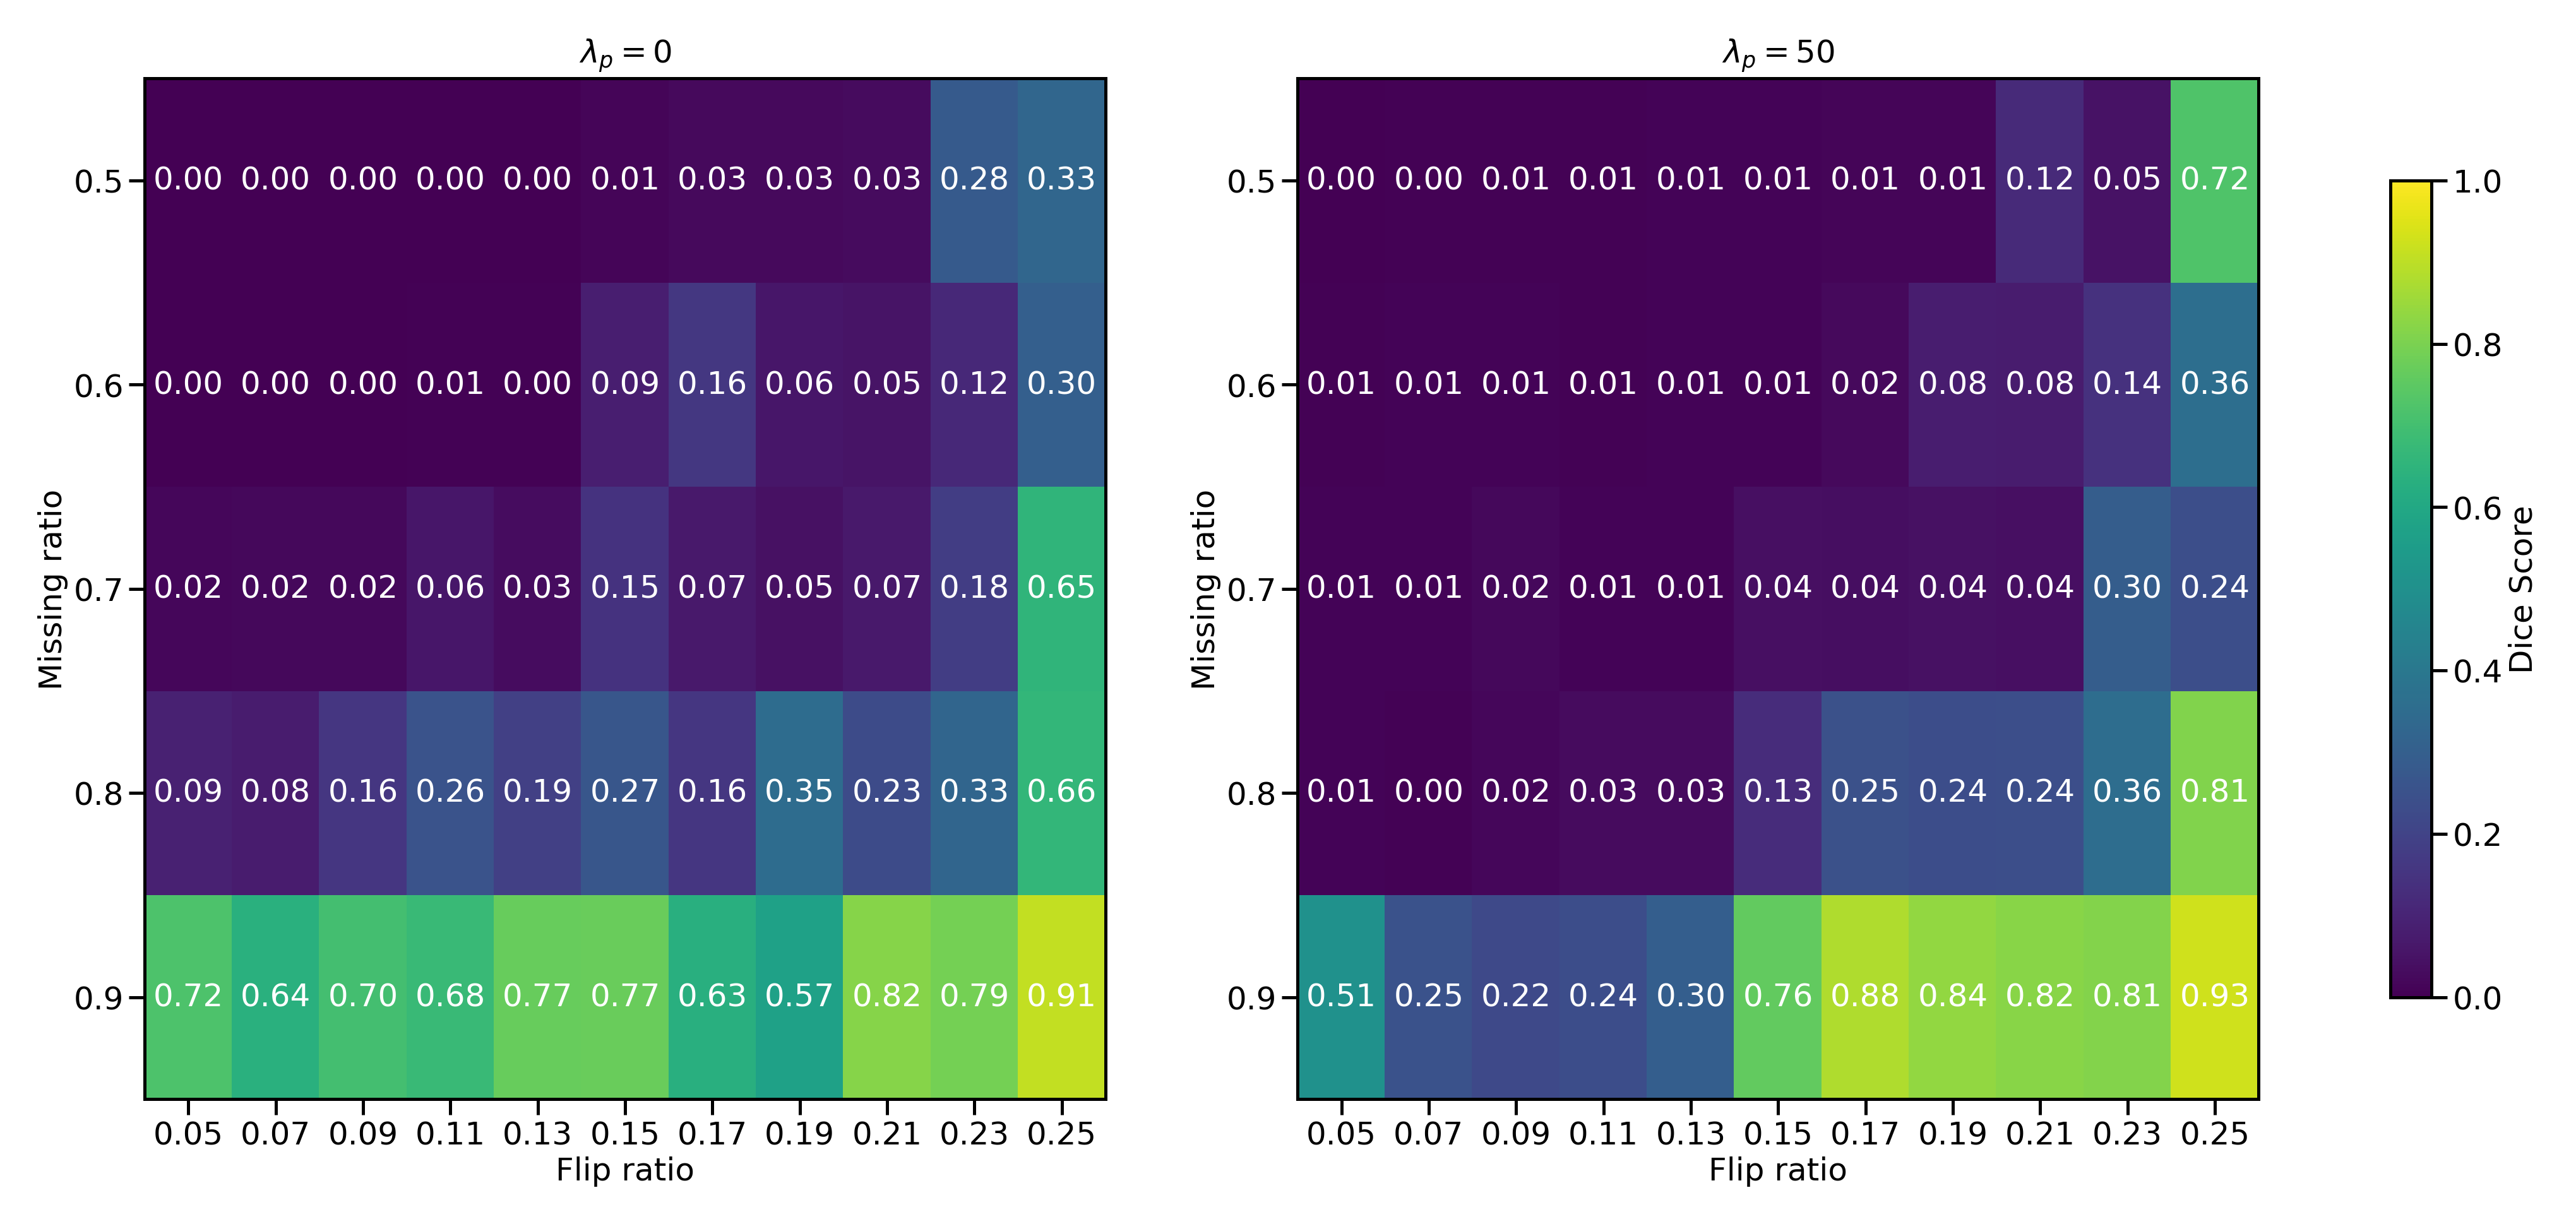

In [44]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.analysis import surface_dice
# from pinn.analysis import calc_area_mem, calc_bend_mem, calc_area_seg, calc_bend_seg

# -------------------
# Parameters
# -------------------
lambda_1 = 1000000
step = 10000
epsilon = 0.05
kappa = 1.0
shape = "multi"
data_type = "1115"

# flip_list = np.round(np.arange(0.05, 0.16, 0.01), 2).tolist()
flip_list = np.round(np.arange(0.05, 0.26, 0.02), 2).tolist()
missing_list = [0.5, 0.6, 0.7, 0.8, 0.9]

# If you want missing ratios in descending order on the axis:
missing_list_plot = sorted(missing_list, reverse=True)

mrc_path = f"../data/synthetic/{shape}.mrc"
# area_true = area_mem[shape]
# bend_true = bend_mem[shape]

# -------------------
# Helper: compute heatmap for a given lambda_2
# -------------------
def compute_heatmap(lambda_2):
    # heatmap[i, j] : i -> flip_list index, j -> missing_list index
    heatmap = np.full((len(flip_list), len(missing_list)), np.nan)

    for i, flip_ratio in enumerate(flip_list):
        for j, missing_ratio in enumerate(missing_list):

            flip_str = str(flip_ratio).replace('.', '')
            missing_str = str(missing_ratio).replace('.', '')

            ckpt_dir = os.path.abspath(
                f"../outputs/logs/{shape}/data_{data_type}/combine/"
                f"a{flip_str}_m{missing_str}/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}"
            )

            if not os.path.exists(ckpt_dir):
                # no checkpoint -> leave as NaN
                continue

            dat_seg = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)

            dice_val = surface_dice(
                mrc_path, dat_seg,
                grid_size=64, threshold=0.6, band_thickness=0.4
            )

            heatmap[i, j] = float(dice_val)

    return heatmap

# -------------------
# Compute heatmaps for different lambda_p
# -------------------
heatmap_0  = compute_heatmap(lambda_2=0)
heatmap_50 = compute_heatmap(lambda_2=50)

heatmaps = [heatmap_0, heatmap_50]
titles   = [r"$\lambda_p = 0$", r"$\lambda_p = 50$"]

# -------------------
# Global vmin/vmax for all panels (optional)
# -------------------
all_data = np.concatenate([h[~np.isnan(h)].ravel() for h in heatmaps if not np.all(np.isnan(h))])
vmin = 0.0         # or: np.nanmin(all_data)
vmax = 1.0         # or: np.nanmax(all_data)

# -------------------
# Plot side-by-side
# -------------------
plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

    for ax, H, title in zip(axes, heatmaps, titles):

        # transpose so row = missing, col = flip
        H_plot = H.T

        # reorder rows according to missing_list_plot (descending)
        # missing_list indices mapping:
        idx_map = [missing_list.index(m) for m in missing_list_plot]
        H_plot = H_plot[idx_map, :]

        im = ax.imshow(
            H_plot,
            origin="lower",
            aspect="auto",
            vmin=vmin,
            vmax=vmax,
        )

        n_rows, n_cols = H_plot.shape  # rows: missing, cols: flip

        ax.set_xticks(np.arange(n_cols))
        ax.set_yticks(np.arange(n_rows))

        ax.set_xticklabels(flip_list)
        ax.set_yticklabels(missing_list_plot)

        ax.set_xlabel("Flip ratio")
        ax.set_ylabel("Missing ratio")
        ax.set_title(title)

        # Annotate cells safely
        for i in range(n_rows):      # rows
            for j in range(n_cols):  # cols
                val = H_plot[i, j]
                if np.isnan(val):
                    continue
                ax.text(j, i, f"{val:.2f}",
                        ha="center", va="center", color="white")

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
    cbar.set_label("Dice Score")

plt.show()


In [9]:
import os
import numpy as np
from flax.training import checkpoints
from pinn.analysis import calc_area_seg, calc_bend_seg, surface_dice
from tqdm import tqdm

def compute_heatmap(
    x_list,
    y_list,
    noise_type,
    shape,
    data_type,
    step,
    mrc_path,
    lambda_1,
    lambda_2,
    epsilon = 0.05,
    kappa = 1.0,
    flip_ratio_for_wedge=0.1,
    grid_size=64,
    threshold=0.6,
    band_thickness=0.4,
    num_point=10000,
):
    # --- initialize storage (match loop dimensions) ---
    dice_map = np.full((len(x_list), len(y_list)), np.nan, dtype=float)
    area_map = np.full((len(x_list), len(y_list)), np.nan, dtype=float)
    bend_map = np.full((len(x_list), len(y_list)), np.nan, dtype=float)

    for i, x_val in enumerate(tqdm(x_list, desc="Processing x_list")):
        for j, y_val in enumerate(y_list):

            if noise_type == "combine":
                flip_str = str(x_val).replace(".", "")
                missing_str = str(y_val).replace(".", "")

                ckpt_dir = os.path.abspath(
                    f"../outputs/logs/{shape}/data_{data_type}/combine/"
                    f"a{flip_str}_m{missing_str}/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}"
                )

            elif noise_type == "wedge":
                flip_str = str(flip_ratio_for_wedge).replace(".", "")
                axis_angle = int(x_val)
                tilt_max = int(y_val)

                ckpt_dir = os.path.abspath(
                    f"../outputs/logs/{shape}/data_{data_type}/wedge/"
                    f"a{flip_str}_w{axis_angle:02d}_t{tilt_max:02d}/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}"
                )

            else:
                raise ValueError(f"Unknown noise_type: {noise_type}")

            if not os.path.exists(ckpt_dir):
                continue

            # --- load checkpoint ---
            dat_seg = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)

            # --- compute metrics ---
            area_seg_val = calc_area_seg(dat_seg, epsilon=epsilon, sampling="random", num_point=num_point)
            bend_seg_val = calc_bend_seg(dat_seg, epsilon=epsilon, kappa=kappa, sampling="random", num_point=num_point)
            dice_val = surface_dice(mrc_path, dat_seg, grid_size=grid_size, threshold=threshold, band_thickness=band_thickness)

            # --- store results ---
            dice_map[i, j] = float(dice_val)
            area_map[i, j] = float(area_seg_val)
            bend_map[i, j] = float(bend_seg_val)

    # --- save results ---
    out_dir = os.path.abspath(f"../outputs/logs/{shape}/data_{data_type}/{noise_type}")
    os.makedirs(out_dir, exist_ok=True)

    out_path = os.path.join(out_dir, f"heatmap_{lambda_1}_{lambda_2}.npz")
    np.savez(out_path, dice=dice_map, area=area_map, bend=bend_map)

    return {"dice": dice_map, "area": area_map, "bend": bend_map}

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def plot_heatmaps_two(
    H0, H50,
    x_list, y_list,
    title0=r"$\lambda_p = 0$",
    title50=r"$\lambda_p = 50$",
    x_label="x_list",
    y_label="y_list",
    cbar_label="Dice Score",
    vmin=0.0,
    vmax=1.0,
    annotate=False,
    fmt="{:.2f}",
    figsize=(8, 3),
    wspace=0.25,
    cbar_pad=0.04,
    cbar_shrink=0.9,
):
    """
    H0, H50 shape: (len(x_list), len(y_list)) where H[i,j] corresponds to x_list[i], y_list[j].
    Plots two panels: H0 and H50. Uses one shared colorbar.
    """

    H0 = np.asarray(H0, dtype=float)
    H50 = np.asarray(H50, dtype=float)

    # For imshow we want rows=y, cols=x
    H0_plot = H0.T
    H50_plot = H50.T

    n_rows, n_cols = H0_plot.shape

    plt.style.reload_library()
    with plt.style.context(["base", "transparent"]):
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        fig.subplots_adjust(wspace=wspace)

        im0 = axes[0].imshow(H0_plot, origin="lower", aspect="auto", vmin=vmin, vmax=vmax)
        axes[0].set_title(title0)

        im1 = axes[1].imshow(H50_plot, origin="lower", aspect="auto", vmin=vmin, vmax=vmax)
        axes[1].set_title(title50)

        # shared ticks/labels
        for ax in axes:
            ax.set_xticks(np.arange(n_cols))
            ax.set_yticks(np.arange(n_rows))
            ax.set_xticklabels(x_list)
            ax.set_yticklabels(y_list)
            ax.set_xlabel(x_label)
            ax.set_ylabel(y_label)

        # annotations
        if annotate:
            def annotate_ax(ax, Hplot):
                for i in range(n_rows):
                    for j in range(n_cols):
                        val = Hplot[i, j]
                        if np.isnan(val):
                            continue
                        ax.text(j, i, fmt.format(val),
                                ha="center", va="center", color="white")
            annotate_ax(axes[0], H0_plot)
            annotate_ax(axes[1], H50_plot)

        # one shared colorbar (stable placement)
        cbar = fig.colorbar(im1, ax=axes, shrink=cbar_shrink, pad=cbar_pad)
        cbar.set_label(cbar_label)

    return fig, axes



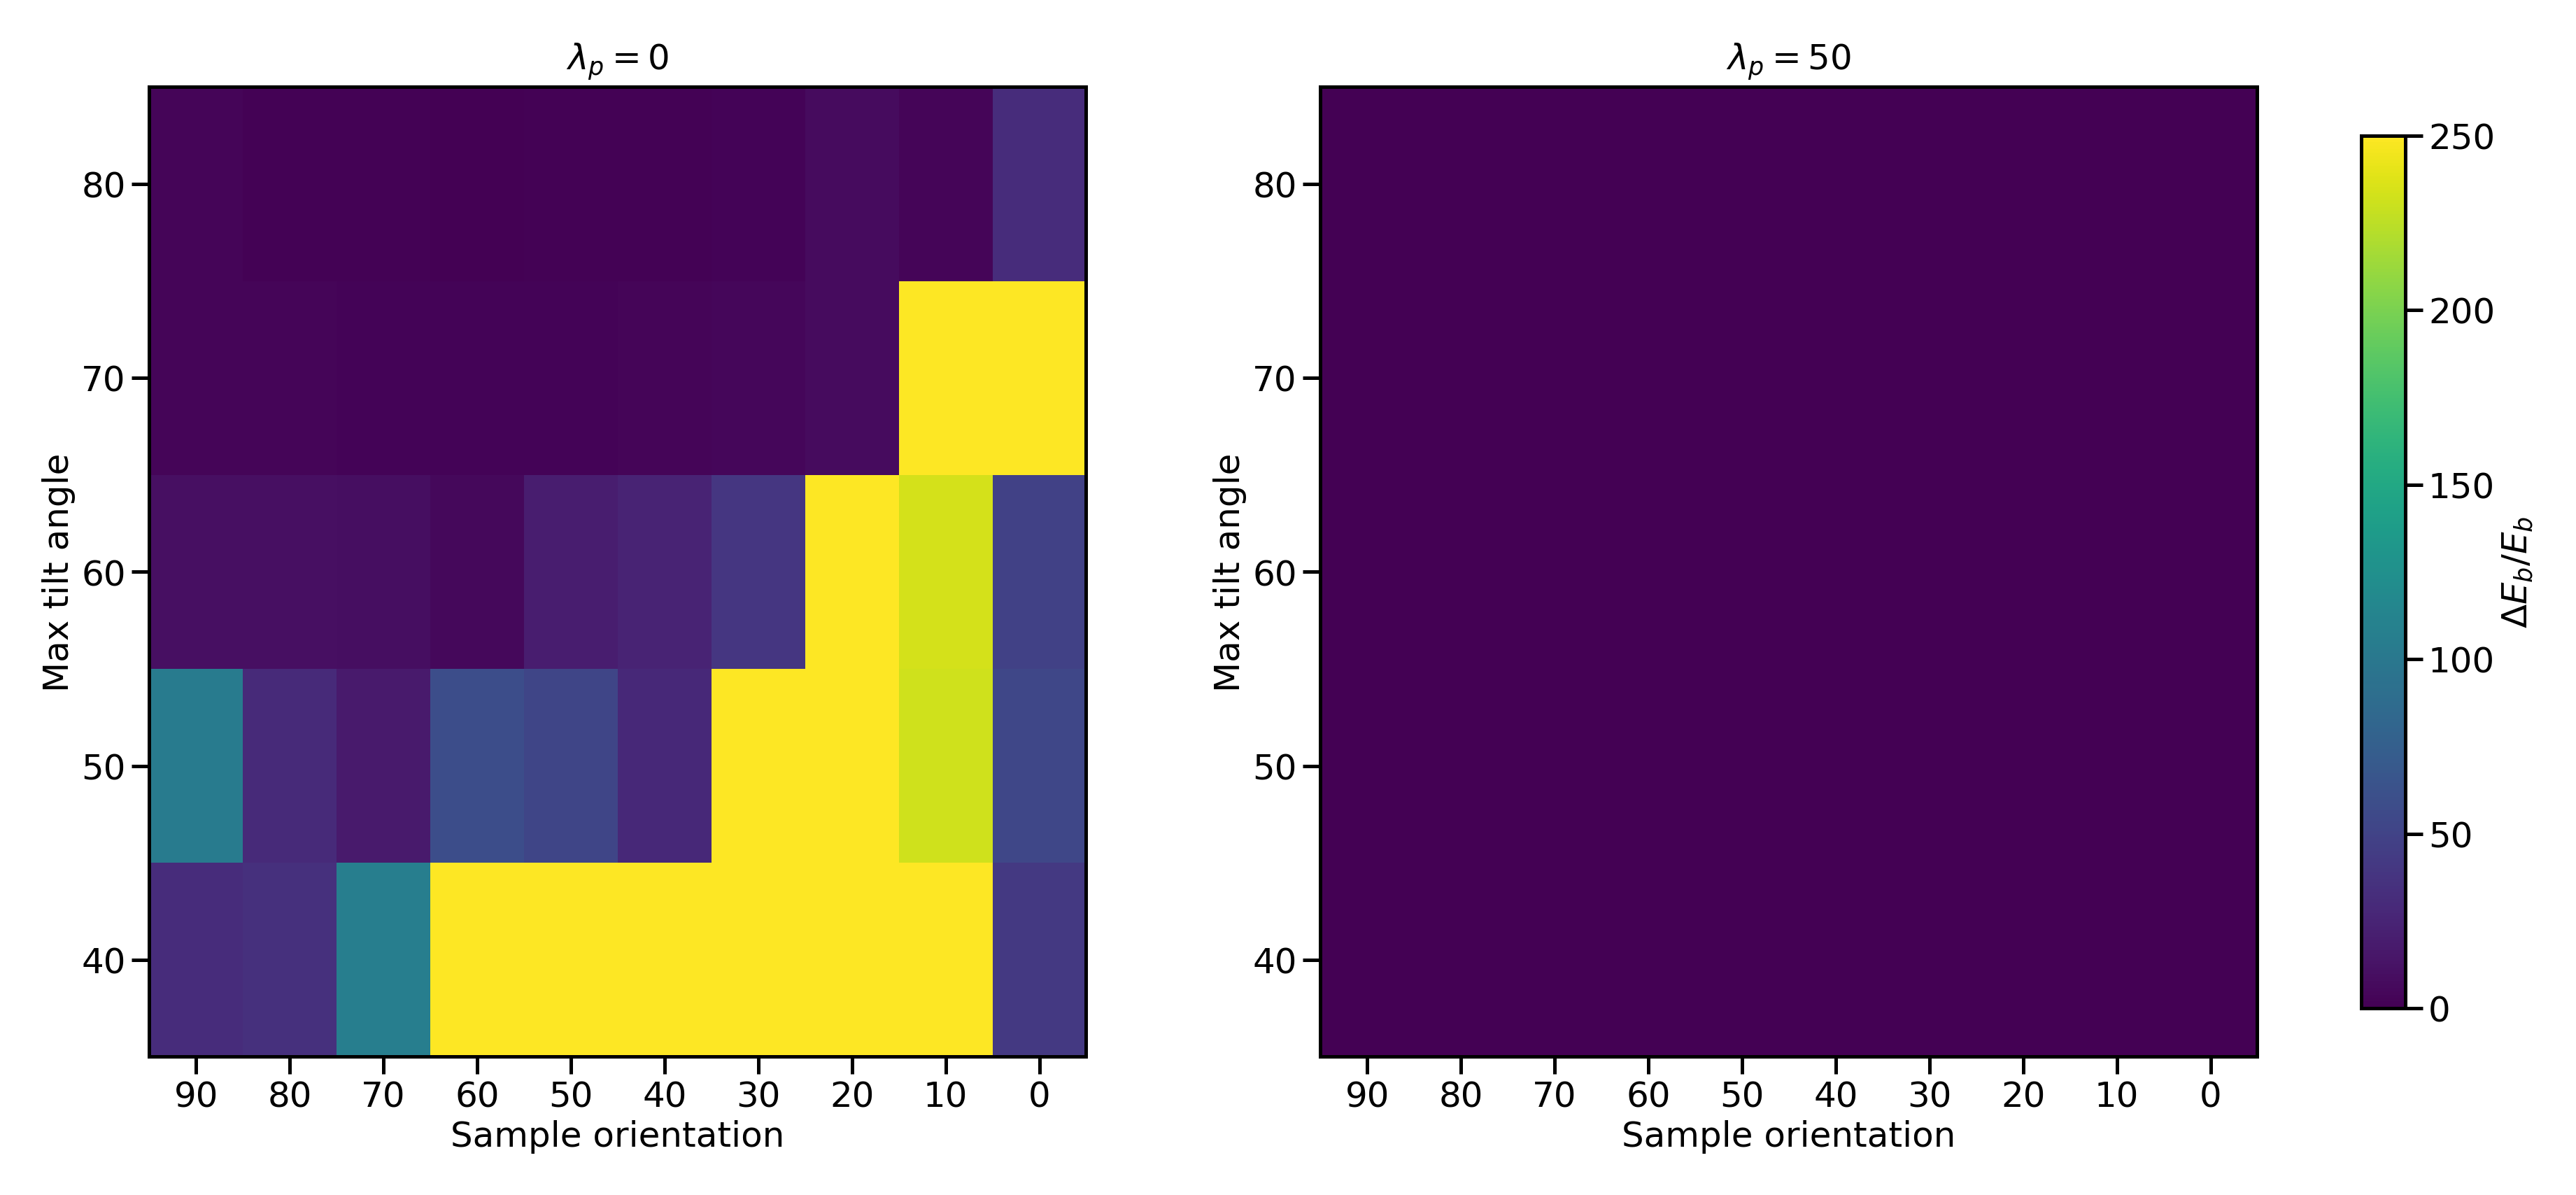

In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints

# -------------------
# Parameters
# -------------------
lambda_1 = 1000000
step = 10000
epsilon = 0.05
kappa = 1.0
shape = "multi"
data_type = "1115"
# plot_type = "dice"
# plot_type = "area"
plot_type = "bend"

# noise_type = "combine"
# x_list = np.round(np.arange(0.05, 0.26, 0.02), 2).tolist() # flip_list
# y_list = [0.5, 0.6, 0.7, 0.8, 0.9] # missing_list
# y_list = sorted(y_list, reverse=True)
# x_label = "Additive noise"
# y_label = "Subtractive noise"

noise_type = "wedge"
x_list = list(range(90, -1, -10)) # axis_angle
y_list = [40, 50, 60, 70, 80] # tilt_max
x_label = "Sample orientation"
y_label = "Max tilt angle"


if plot_type == "dice":
    gt = 0
    denom = 1
    vmin = 0
    vmax = 1
    diff_vlim = 0.2
    cbar_label = "Dice score"
elif plot_type == "area":
    gt = area_mem[shape]
    denom = gt
    vmin = 0
    vmax = 1.75
    diff_vlim = 0.2
    cbar_label = r"$\Delta E_s / E_s$"
elif plot_type == "bend":
    gt = bend_mem[shape]
    denom = gt
    vmin = 0
    vmax = 250
    diff_vlim = 100
    cbar_label = r"$\Delta E_b / E_b$"

# -------------------
# Compute or import heatmaps
# -------------------
mrc_path = f"../data/synthetic/{shape}.mrc"
# heatmap_0  = compute_heatmap(x_list, y_list, noise_type, shape, data_type, step, mrc_path, lambda_1, lambda_2=0)
# heatmap_50 = compute_heatmap(x_list, y_list, noise_type, shape, data_type, step, mrc_path, lambda_1, lambda_2=50)
heatmap_0  = np.load(f"../outputs/logs/{shape}/data_{data_type}/{noise_type}/heatmap_{lambda_1}_0.npz")
heatmap_50 = np.load(f"../outputs/logs/{shape}/data_{data_type}/{noise_type}/heatmap_{lambda_1}_50.npz")

data_0  = abs(heatmap_0 [plot_type] - gt) / denom
data_50 = abs(heatmap_50[plot_type] - gt) / denom

heatmaps = [data_0, data_50]
titles   = [r"$\lambda_p = 0$", r"$\lambda_p = 50$"]

fig, axes = plot_heatmaps_two(
    data_0, data_50,
    x_list=x_list,
    y_list=y_list,
    x_label=x_label,
    y_label=y_label,
    cbar_label=cbar_label,
    vmin=vmin,
    vmax=vmax,
)

# plt.savefig(f"../outputs/figs/sync/noise/heatmap_{shape}_{plot_type}.png", dpi=600, bbox_inches="tight")
plt.savefig(f"../outputs/figs/sync/wedge/heatmap_{shape}_{plot_type}.png", dpi=600, bbox_inches="tight")

plt.show()

In [24]:
data_0

array([[4.74870205e-04, 5.24318218e-03, 5.34773469e-02, 1.20314598e-01,
        1.55339479e-01],
       [5.96046448e-08, 6.88213110e-03, 3.79809141e-02, 1.08129382e-01,
        2.32655227e-01],
       [0.00000000e+00, 2.37888098e-03, 4.05036211e-02, 1.33586228e-01,
        1.55027330e-01],
       [1.19209290e-07, 2.66516209e-03, 4.90288138e-02, 1.47537410e-01,
        1.79055333e-01],
       [9.49501991e-05, 4.22453880e-03, 4.51130867e-02, 5.31702638e-02,
        2.49160707e-01],
       [0.00000000e+00, 6.48742914e-03, 7.21265674e-02, 1.72648549e-01,
        5.30871868e-01],
       [7.59959221e-04, 2.33200788e-02, 1.58929110e-01, 3.96559298e-01,
        4.05034244e-01],
       [1.52122974e-03, 1.08687401e-01, 3.90637040e-01, 3.92504394e-01,
        5.46673954e-01],
       [3.38601470e-02, 2.57823050e-01, 3.40220928e-01, 4.03086543e-01,
        6.58573329e-01],
       [1.80287480e-01, 2.74427593e-01, 2.77036488e-01, 3.79432440e-01,
        5.12008071e-01]])

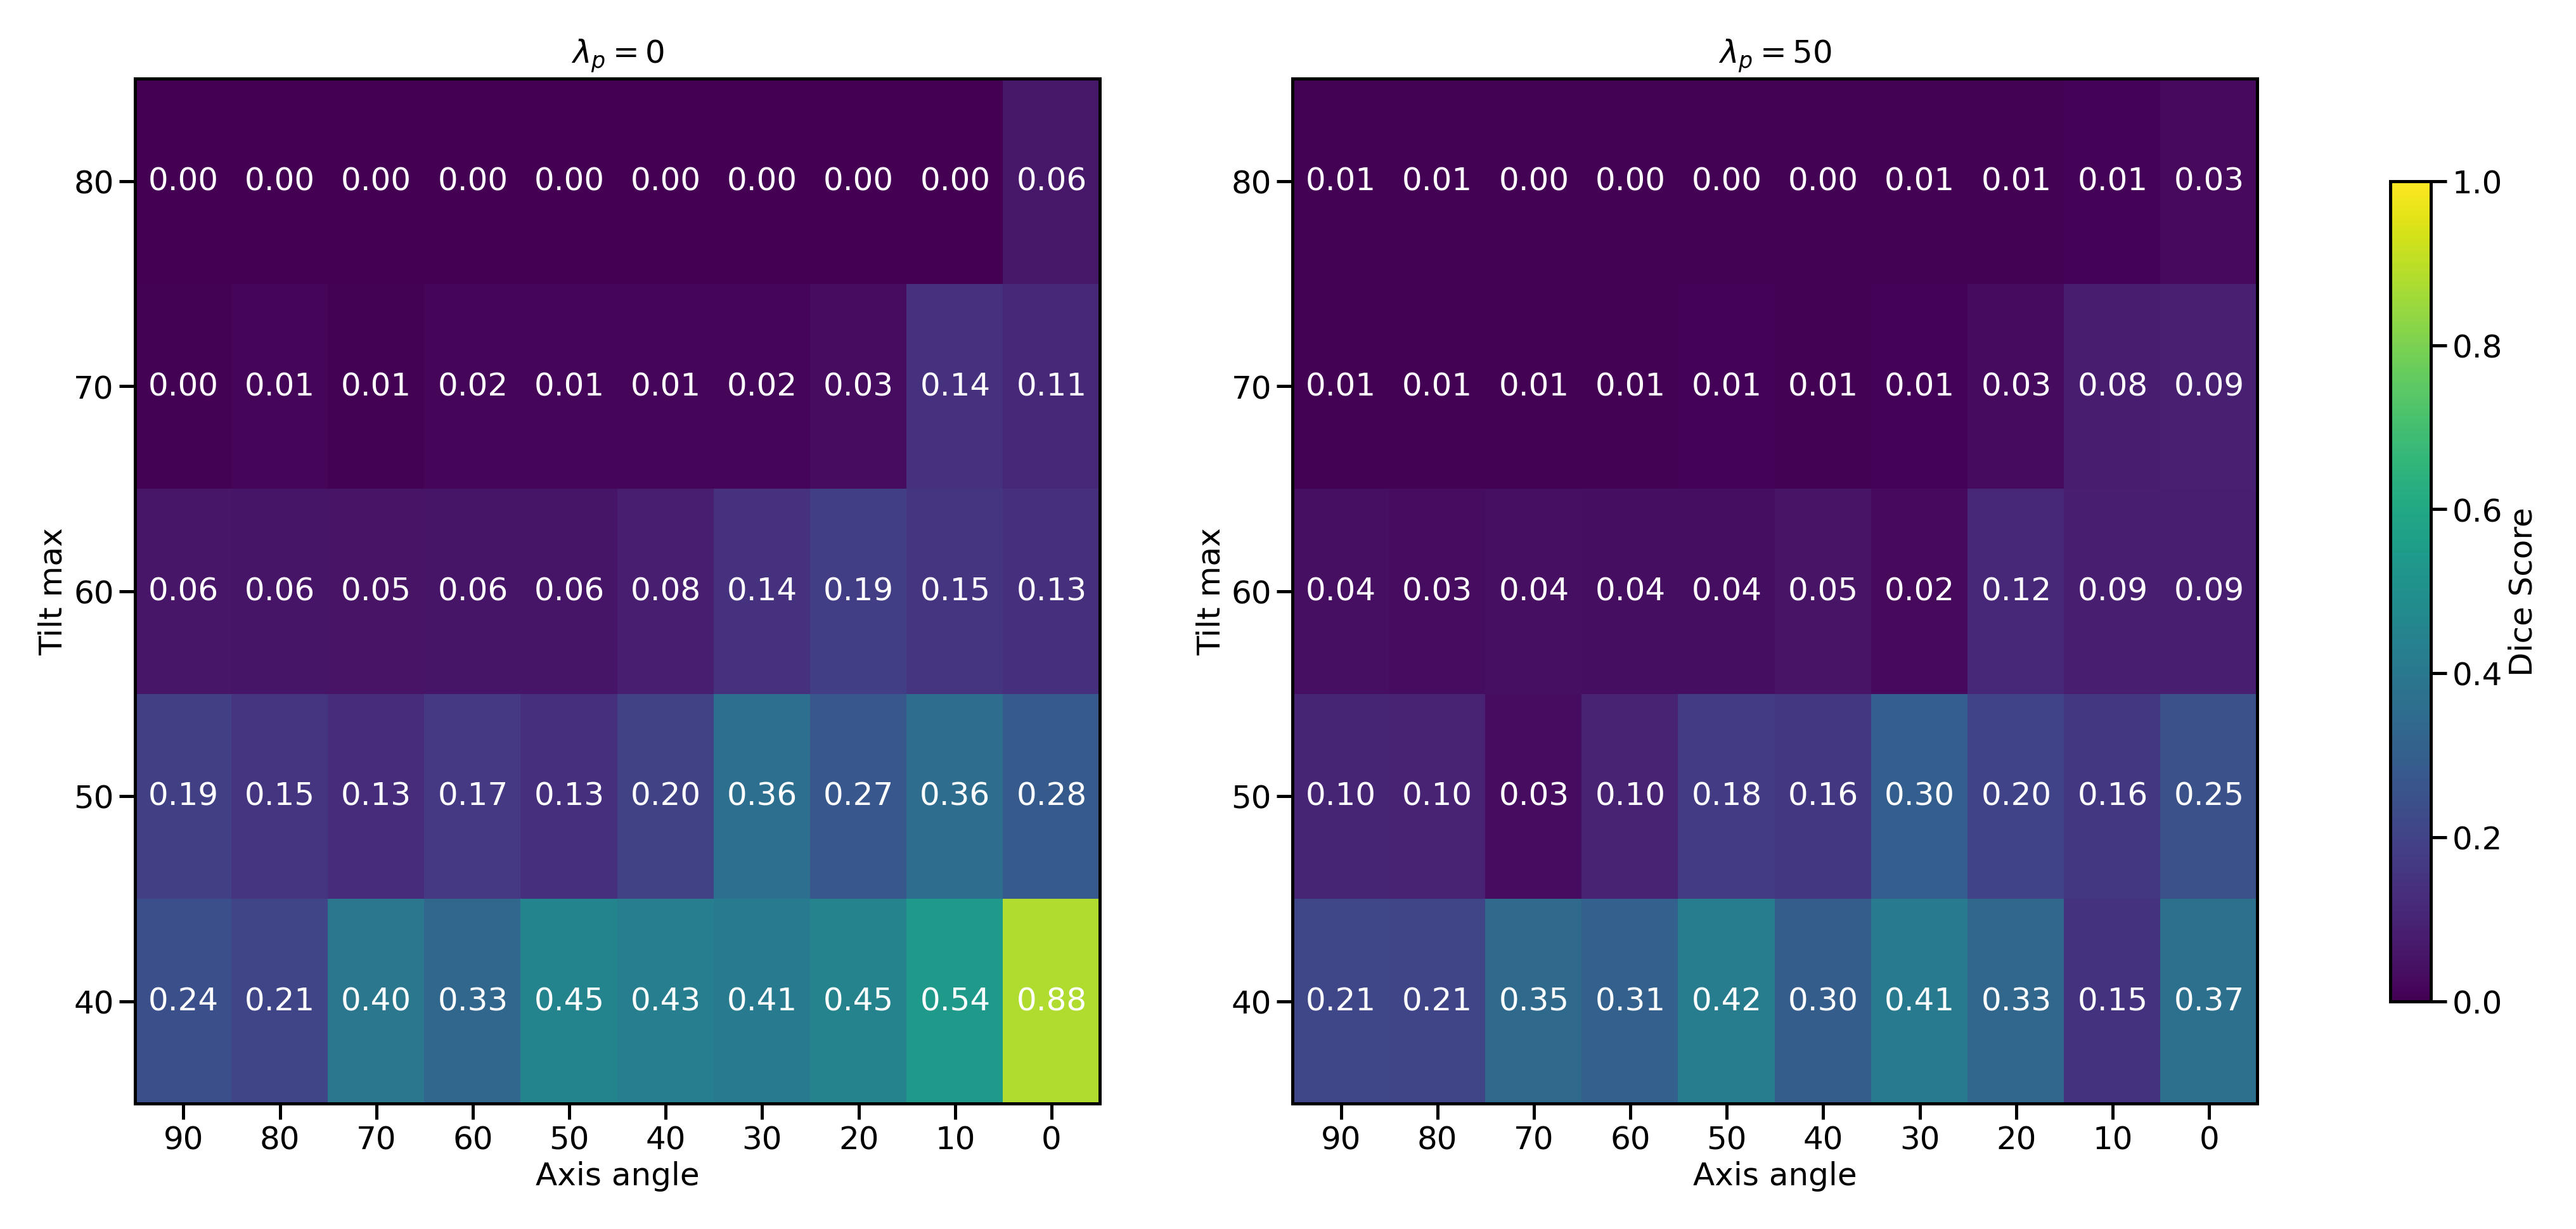

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.analysis import surface_dice
# from pinn.analysis import calc_area_mem, calc_bend_mem, calc_area_seg, calc_bend_seg

# -------------------
# Parameters
# -------------------
lambda_1 = 1000000
step = 10000
epsilon = 0.05
kappa = 1.0
shape = "multi"
data_type = "1115"
flip_ratio = 0.1

# axis_angle_list = [90, 60, 30, 0]
axis_angle_list = list(range(90, -1, -10))
tilt_max_list = [80, 70, 60, 50, 40]

mrc_path = f"../data/synthetic/{shape}.mrc"
# area_true = area_mem[shape]
# bend_true = bend_mem[shape]

# -------------------
# Helper: compute heatmap for a given lambda_2
# -------------------
def compute_heatmap(lambda_2):
    heatmap = np.full((len(axis_angle_list), len(tilt_max_list)), np.nan)

    for i, axis_angle in enumerate(axis_angle_list):
        for j, tilt_max in enumerate(tilt_max_list):

            flip_str = str(flip_ratio).replace('.', '')

            ckpt_dir = os.path.abspath(
                f"../outputs/logs/{shape}/data_{data_type}/wedge/"
                f"a{flip_str}_w{axis_angle:02d}_t{tilt_max:02d}/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}"
            )

            if not os.path.exists(ckpt_dir):
                # no checkpoint -> leave as NaN
                continue

            dat_seg = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)

            dice_val = surface_dice(
                mrc_path, dat_seg,
                grid_size=64, threshold=0.6, band_thickness=0.4
            )

            heatmap[i, j] = float(dice_val)

    return heatmap

# -------------------
# Compute heatmaps for different lambda_p
# -------------------
heatmap_0  = compute_heatmap(lambda_2=0)
heatmap_50 = compute_heatmap(lambda_2=50)

heatmaps = [heatmap_0, heatmap_50]
titles   = [r"$\lambda_p = 0$", r"$\lambda_p = 50$"]

# -------------------
# Global vmin/vmax for all panels (optional)
# -------------------
all_data = np.concatenate([h[~np.isnan(h)].ravel() for h in heatmaps if not np.all(np.isnan(h))])
vmin = 0.0         # or: np.nanmin(all_data)
vmax = 1.0         # or: np.nanmax(all_data)

# -------------------
# Plot side-by-side
# -------------------
plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

    # Reverse tilt order for display: top→bottom = 80,70,60,50
    tilt_display = tilt_max_list[::-1]      # [80,70,60,50]
    idx_tilt     = np.arange(len(tilt_display))[::-1]  # [3,2,1,0]

    for ax, H, title in zip(axes, heatmaps, titles):

        # H shape = (len(axis_angle_list), len(tilt_max_list))
        # We want:
        #   - columns = axis_angle
        #   - rows = tilt_max (reversed)
        H_plot = H.T[idx_tilt, :]   # reorder rows so 80 is on top

        im = ax.imshow(
            H_plot,
            origin="lower",       # row 0 at bottom → after reversing: 50 at bottom, 80 at top
            aspect="auto",
            vmin=vmin,
            vmax=vmax,
        )

        n_rows, n_cols = H_plot.shape

        ax.set_xticks(np.arange(n_cols))
        ax.set_yticks(np.arange(n_rows))

        ax.set_xticklabels(axis_angle_list)
        ax.set_yticklabels(tilt_display)     # show 80 → 50

        ax.set_xlabel("Axis angle")
        ax.set_ylabel("Tilt max")
        ax.set_title(title)

        # Annotate cells
        for i in range(n_rows):
            for j in range(n_cols):
                val = H_plot[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f"{val:.2f}",
                            ha="center", va="center", color="white")

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
    cbar.set_label("Dice Score")

plt.show()
